<Figure size 1000x600 with 0 Axes>

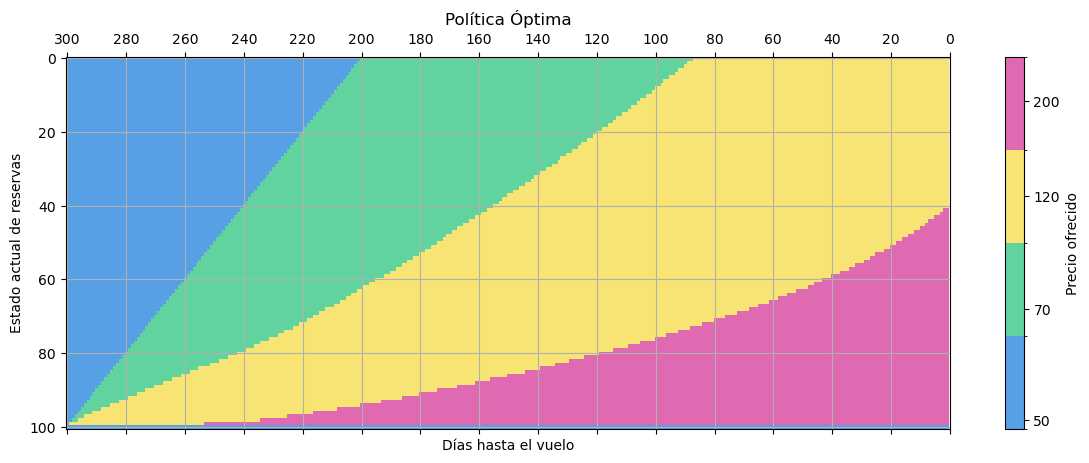

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Parámetros
T = 300
S = 101
A = [50, 70, 120, 200]

# Distribuciones condicionales de disposición a pagar
p_turista = {50: 1, 70: 0.5, 120: 1/6, 200: 0}
p_pro =     {50: 1, 70: 1,   120: 0.5, 200: 1/6}

# Función p_t(t): probabilidad de que el pasajero del día t sea turista
def p_t(t):
    return 1 - np.exp(-t / 30)

# Probabilidad total de aceptación para precio a en día t
def p_accept(t, a):
    return p_t(t) * p_turista[a] + (1 - p_t(t)) * p_pro[a]

# Recompensa esperada al ofrecer precio a en día t
def reward(t, a):
    return a * p_accept(t, a)

# Algoritmo de programación dinámica hacia atrás
def backward_dp():
    V = np.zeros((T + 1, S))            # Valor óptimo esperado
    pi = np.zeros((T, S), dtype=int)    # Política óptima

    for t in reversed(range(T)):
        for x in range(S):
            best_value = -np.inf
            best_action = None
            for i, a in enumerate(A):
                if x == S - 1:
                    v = 0
                else:
                    p = p_accept(t, a)
                    v = reward(t, a) + p * V[t + 1, x + 1] + (1 - p) * V[t + 1, x]
                if v > best_value:
                    best_value = v
                    best_action = i
            V[t, x] = best_value
            pi[t, x] = best_action
    return V, pi

# Ejecutar la optimización
V, pi = backward_dp()
pi_prices = np.array(A)[pi]  # matriz T x S con precios en cada estado

# Las lineas siguientes se usan para mantener el mismo esquema de colores y orientacion de los ejes que el código original
a = pi_prices.T
colors = ["#58a0e5", "#61d39f", "#f8e473", "#e06ab2"]
cmap = ListedColormap(colors)
bounds = [49, 60, 95, 145, 250]
norm = BoundaryNorm(bounds, cmap.N)

# Crear figura
plt.figure(figsize=(10, 6))
im = plt.matshow(a[:, ::-1], cmap=cmap, norm=norm, aspect='auto')
plt.xticks(range(0, T + 1, 20), range(T, -1, -20))
plt.xlabel('Días hasta el vuelo')
plt.ylabel('Estado actual de reservas')
plt.title('Política Óptima')
plt.colorbar(im, ticks=A, label="Precio ofrecido")
plt.grid(True)
plt.show()